# Comparaison inférences : checkpoint vs tuile stockée

Ce notebook permet de comparer, sur une fenêtre identique :
- **Inférence live** : calculée à la volée depuis un checkpoint
- **Inférence stockée** : résultat déjà écrit sur le Store DAI

Les métriques et visuels sont calculés uniquement sur les **dates synthétiquement masquées et originalement sans nuages** (convention `cloud == 150` dans le GT).

## 0 · Configuration

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").parent.resolve()))

# ── Tuile à analyser ─────────────────────────────────────────────────────────
MGRS25 = "30TXR_row-3_col-3"   # ex: '30TXR_row-3_col-3'

# Fenêtre à extraire (col_off, row_off, width, height) en pixels dans la tuile
WINDOW = (512, 512, 256, 256)

# ── Paths Store DAI ──────────────────────────────────────────────────────────
from pathlib import Path

STORE_DAI = Path("/mnt/stores/store_dai")

# Répertoire des inférences déjà stockées
PATH_STORED_INFERENCES = STORE_DAI / "tmp/speillet/inferences/v3_combined/consecutive_fully_masked/2026-03-26_16-17"

# Répertoire GT (rasters bands_stacked)
GT_PATH_DIR = STORE_DAI / "projets/pac/3str/EXP_2/Data_Raster/test_v3/consecutif"

# Répertoire des masques synthétiques
DATA_MASKS_DIR = STORE_DAI / "projets/pac/3str/EXP_2/Data_Raster/test_v3/consecutif"

# Données optiques et radar pour Dataset_from_files
DATA_OPTIQUE  = Path("/mnt/stores/store_dai/projets/pac/3str/EXP_2/Data_Raster/optique_dataset")
DATA_RADAR    = Path("/mnt/stores/store_dai/projets/pac/3str/EXP_2/Data_Raster/radar_dataset_v4")

# ── Checkpoint ───────────────────────────────────────────────────────────────
CHECKPOINT   = Path("/mnt/stores/store_dai/tmp/speillet/cloud_reconstruction_results/U-TILISE/v3_mix_closest_random_clouds_combined/2026-03-26_16-17/checkpoints/Model_best.pth")
CONFIG_TRAIN = Path("/mnt/stores/store_dai/tmp/speillet/cloud_reconstruction_results/U-TILISE/v3_mix_closest_random_clouds_combined/2026-03-26_16-17/config.yaml")

# ── Paramètres du modèle (doit correspondre au checkpoint) ───────────────────
MASK_TYPE       = "consecutive_fully_masked"   # 'random_fully_masked' ou 'consecutive_fully_masked'
USE_SAR         = "mix_closest"
FILL_VALUE      = 1
IMAGE_SIZE      = [256, 256]
OVERLAP         = 0

# ── Constantes visuelles ─────────────────────────────────────────────────────
RGB_INDICES     = [2, 1, 0]        # B4, B3, B2 → R, G, B
BRIGHTNESS      = 3.0              # facteur de brillance pour l'affichage
MAX_PIXEL_VALUE = 10_000
BAND_NAMES      = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]

print("Configuration OK")

Configuration OK


## 1 · Chargement du GT et de l'inférence stockée

In [2]:
import math
import numpy as np
import rasterio
from rasterio.windows import Window

SYNTHETIC_THRESHOLD = 100
SYNTHETIC_OFFSET    = 150

col_off, row_off, win_w, win_h = WINDOW
window = Window(col_off, row_off, win_w, win_h)

# ── Chemins des fichiers ──────────────────────────────────────────────────────
tile_root  = MGRS25.split("_")[0]   # ex: '30TXR'
subtile    = "MGRS25-" + "_".join(MGRS25.split("_"))
stored_tif = PATH_STORED_INFERENCES / f"pred_mgrsc_{MGRS25}.tif"
gt_tif     = GT_PATH_DIR / tile_root / subtile / f"bands_stacked_{MGRS25}.tif"

assert stored_tif.exists(), f"Inférence stockée introuvable : {stored_tif}"
assert gt_tif.exists(),     f"GT introuvable : {gt_tif}"

# ── Lecture des rasters sur la fenêtre ───────────────────────────────────────
with rasterio.open(stored_tif) as src:
    raw_stored = src.read(window=window)   # (T*12, H, W)

with rasterio.open(gt_tif) as src:
    raw_gt    = src.read(window=window)    # (T*12, H, W)
    gt_meta   = src.meta.copy()

H, W   = raw_gt.shape[-2], raw_gt.shape[-1]
T_tot  = raw_gt.shape[0] // 12
print(f"Fenêtre : {H}×{W} px  |  T_total = {T_tot} dates")

# ── Reshape en (T, 12, H, W) ─────────────────────────────────────────────────
stored_4d = raw_stored.reshape(T_tot, 12, H, W)
gt_4d     = raw_gt.reshape(T_tot, 12, H, W)

# ── Identification des dates synthétiques ────────────────────────────────────
cloud_gt  = gt_4d[:, 10]                         # (T, H, W)
idx_synth = np.unique(np.where(cloud_gt > SYNTHETIC_THRESHOLD)[0])
max_cloud = cloud_gt[idx_synth].max(axis=(1, 2))
idx_real  = idx_synth[max_cloud == SYNTHETIC_OFFSET]   # dates claires masquées synthétiquement

print(f"Dates synthétiques    : {len(idx_synth)}")
print(f"Dates claires masquées: {len(idx_real)}  (indices : {idx_real})")

# ── Extraction et normalisation ───────────────────────────────────────────────
def to_float(arr_uint16):
    """(T, 10, H, W) uint16 → float32 [0, 1], nodata=0 reste 0."""
    return np.where(arr_uint16 == 0, 0.0, (arr_uint16 - 1000.0) / MAX_PIXEL_VALUE).astype(np.float32)

gt_valid     = to_float(gt_4d[idx_real, :10])      # (N, 10, H, W)
stored_valid = (stored_4d[idx_real, :10].astype(np.float32) / MAX_PIXEL_VALUE)  # déjà en [0, 10000]
nodata_mask  = gt_4d[idx_real, 0] != 0             # (N, H, W) True = pixel valide

print(f"\nTenseurs extraits : {gt_valid.shape}   (N_dates, 10 bandes, {H}, {W})")
print(f"Pixels valides    : {nodata_mask.sum()} / {nodata_mask.size}")

Fenêtre : 256×256 px  |  T_total = 75 dates
Dates synthétiques    : 12
Dates claires masquées: 4  (indices : [0 2 3 4])

Tenseurs extraits : (4, 10, 256, 256)   (N_dates, 10 bandes, 256, 256)
Pixels valides    : 262096 / 262144


## 2 · Inférence live depuis le checkpoint

In [3]:
import torch
from torch.utils.data import DataLoader

from dataloader_CIRCA.datasets.dataset_from_files import Dataset_from_files
from dataloader_CIRCA.tools.data_processor import SentinelDataProcessor
from lib.eval_tools import Imputation

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Dataset pour la tuile ─────────────────────────────────────────────────────
ds = Dataset_from_files(
    mgrsc=MGRS25,
    data_optique=DATA_OPTIQUE,
    data_radar=DATA_RADAR,
    image_size=IMAGE_SIZE,
    overlap=OVERLAP,
    fill_value=FILL_VALUE,
    mask_type="fully_masked",
    data_masks=DATA_MASKS_DIR,
    use_sar=USE_SAR,
    keep_all_dates=False,
)

# ── Trouver le patch correspondant à la fenêtre WINDOW ────────────────────────
# Les fenêtres sont dans la colonne "window" de ds.mgrsc_dataset (DataFrame)
target_window = (col_off, row_off, win_w, win_h)
windows_list = [tuple(w) for w in ds.mgrsc_dataset["window"].tolist()]
patch_idx = None
for i, item in enumerate(windows_list):
    if item == target_window:
        patch_idx = i
        break

assert patch_idx is not None, (
    f"Fenêtre {target_window} introuvable dans le dataset.\n"
    f"Fenêtres disponibles (5 premières) : {windows_list[:5]}"
)
print(f"Patch index dans le dataset : {patch_idx}")

# ── Chargement du batch ───────────────────────────────────────────────────────
batch_raw = ds[patch_idx]
# Ajouter la dimension batch (B=1)
batch = {}
for k, v in batch_raw.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.unsqueeze(0)
    elif isinstance(v, np.ndarray):
        batch[k] = torch.from_numpy(v).unsqueeze(0)
    else:
        batch[k] = v

print(f"x shape     : {batch['x'].shape}   (B, T_kept, C, H, W)")
print(f"idx_kept    : {batch_raw['idx_kept']}")
idx_kept = batch_raw["idx_kept"]

Device : cuda:0


mgrs:   0%|          | 0/35 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/2 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

...

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/1 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

Patch index dans le dataset : 20
x shape     : torch.Size([1, 36, 14, 256, 256])   (B, T_kept, C, H, W)
idx_kept    : [ 0  1  2  3  4  5  6  7  8  9 10 11 14 16 21 28 31 32 34 38 39 41 49 50
 54 56 57 60 61 63 67 69 71 72 73 74]


In [4]:
# ── Chargement du modèle et inférence ─────────────────────────────────────────
# Calcul du nombre de canaux d'entrée
n_channels = 10  # bandes S2
if USE_SAR == "asc+desc":      n_channels += 8
elif USE_SAR in ("asc", "desc", "mix_closest"): n_channels += 4

imputation = Imputation(
    config_file_train=str(CONFIG_TRAIN),
    method="utilise",
    mode=None,
    checkpoint=str(CHECKPOINT),
    config_file_test=str(CONFIG_TRAIN),
    num_channels=n_channels,
    device=device,
)

with torch.no_grad():
    batch_out, y_pred = imputation.impute_sample(batch)

# y_pred : (1, T_kept, 10, H, W) dans [0, 1]
y_pred_np = y_pred.squeeze(0).cpu().numpy()   # (T_kept, 10, H, W)
print(f"y_pred shape : {y_pred_np.shape}")

Checkpoint '/mnt/stores/store_dai/tmp/speillet/cloud_reconstruction_results/U-TILISE/v3_mix_closest_random_clouds_combined/2026-03-26_16-17/checkpoints/Model_best.pth' loaded.
Chosen epoch: 116

y_pred shape : (36, 10, 256, 256)


In [5]:
# ── Alignement sur les dates synthétiques claires (idx_real) ──────────────────
# idx_kept contient les indices dans la série originale (clean + synthétiques)
# idx_real contient les indices originaux des dates synthétiques claires
# On cherche leur position dans idx_kept

pos_in_kept = np.where(np.isin(idx_kept, idx_real))[0]

assert len(pos_in_kept) == len(idx_real), (
    f"Certaines dates de idx_real ({idx_real}) "
    f"ne sont pas dans idx_kept ({idx_kept})"
)

ckpt_valid = y_pred_np[pos_in_kept]   # (N, 10, H, W) dans [0, 1]

print(f"Dates alignées  : {len(pos_in_kept)}")
print(f"Positions dans T_kept : {pos_in_kept}")
print(f"Shapes finaux → gt:{gt_valid.shape}  stored:{stored_valid.shape}  ckpt:{ckpt_valid.shape}")

Dates alignées  : 4
Positions dans T_kept : [0 2 3 4]
Shapes finaux → gt:(4, 10, 256, 256)  stored:(4, 10, 256, 256)  ckpt:(4, 10, 256, 256)


## 3 · Métriques comparatives

In [6]:
import sys
sys.path.insert(0, str(Path(".").parent.resolve()))

from dataloader_CIRCA.datasets.cr_metrics import CloudRemovalMetrics
from rich.console import Console
from rich.table import Table

def compute_metrics_on_window(pred_np, gt_np, valid_mask_np):
    """pred, gt : (N, 10, H, W) float32 [0,1] — valid_mask : (N, H, W) bool."""
    # Shapes attendus par CloudRemovalMetrics : (B, T, C, H, W)
    pred_t  = torch.from_numpy(pred_np).unsqueeze(0).float()         # (1, N, 10, H, W)
    gt_t    = torch.from_numpy(gt_np).unsqueeze(0).float()
    # masks : 1 = masqué (occluded), 0 = observé — ici on veut évaluer sur tous les pixels valides
    # → mask = 0 partout (on évalue sur "observed" pixels, en excluant nodata via nodata_mask)
    # On met mask = 1 sur les nodata pour les exclure des métriques observed
    mask_np = (~valid_mask_np).astype(np.float32)[:, np.newaxis]      # (N, 1, H, W)
    mask_t  = torch.from_numpy(mask_np).unsqueeze(0).float()          # (1, N, 1, H, W)

    cr = CloudRemovalMetrics(
        eval_occluded_observed=True,
        clean_gt_cloudy_pixels=False,
        max_pixel_intensity=1,
    )
    results = cr(target=gt_t, masks=mask_t, predicted=pred_t)
    # On garde uniquement les métriques sur pixels "observed" (= valides)
    return {k.replace("_observed_input_pixels", ""): v
            for k, v in results.items() if "observed_input" in k}


metrics_stored = compute_metrics_on_window(stored_valid, gt_valid, nodata_mask)
metrics_ckpt   = compute_metrics_on_window(ckpt_valid,   gt_valid, nodata_mask)

# ── Affichage rich ────────────────────────────────────────────────────────────
console = Console()
table = Table(
    title=f"[bold bright_blue]Métriques — fenêtre {WINDOW} de {MGRS25}[/bold bright_blue]",
    header_style="bold magenta", show_lines=True,
)
table.add_column("Métrique",         style="cyan",  justify="right")
table.add_column("Inférence stockée",style="yellow", justify="center")
table.add_column("Checkpoint live",  style="green",  justify="center")
table.add_column("Δ (ckpt − stored)",style="white",  justify="center")

FMT = {"mae":".4f","mse":".6f","rmse":".4f","psnr":".2f","ssim":".4f","sam":".4f","r2":".4f"}

def fmt(v, k):
    if v is None or (isinstance(v, float) and not math.isfinite(v)):
        return "[dim]N/A[/dim]"
    return f"{v:{FMT.get(k,'.4f')}}"

all_keys = sorted(set(metrics_stored) | set(metrics_ckpt))
for k in all_keys:
    vs, vc = metrics_stored.get(k, float("nan")), metrics_ckpt.get(k, float("nan"))
    try:
        delta = vc - vs
        delta_str = f"{delta:+.4f}"
        color = "green" if (delta > 0) == (k in ("psnr","ssim","r2")) else "red"
        delta_str = f"[{color}]{delta_str}[/{color}]"
    except Exception:
        delta_str = "[dim]N/A[/dim]"
    table.add_row(k.upper(), fmt(vs, k), fmt(vc, k), delta_str)

console.print(table)

      Métriques — fenêtre (512, 512, 256, 256) de 30TXR_row-3_col-3      
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃    Métrique ┃ Inférence stockée ┃ Checkpoint live ┃ Δ (ckpt − stored) ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│         MAE │      0.2333       │     0.2333      │      +0.0000      │
├─────────────┼───────────────────┼─────────────────┼───────────────────┤
│         MSE │     0.062967      │    0.062990     │      +0.0000      │
├─────────────┼───────────────────┼─────────────────┼───────────────────┤
│        PSNR │       12.01       │      12.01      │      -0.0016      │
├─────────────┼───────────────────┼─────────────────┼───────────────────┤
│          R2 │     -51.6602      │    -51.6798     │      -0.0196      │
├─────────────┼───────────────────┼─────────────────┼───────────────────┤
│        RMSE │      0.2509       │     0.2510      │      +0.0000      │
├─────────────┼───────────────────┼─────────────────┼───────────────────┤
│         SAM │      0.9827       │     0.9826      │      -0.0000      │
├─────────────┼───────────────────┼─────────────────┼───────────────────┤
│ SSIM_IMAGES │      0.2158       │     0.2158      │      -0.0000      │
└─────────────┴───────────────────┴─────────────────┴───────────────────┘

## 4 · Comparaison visuelle — RGB par date

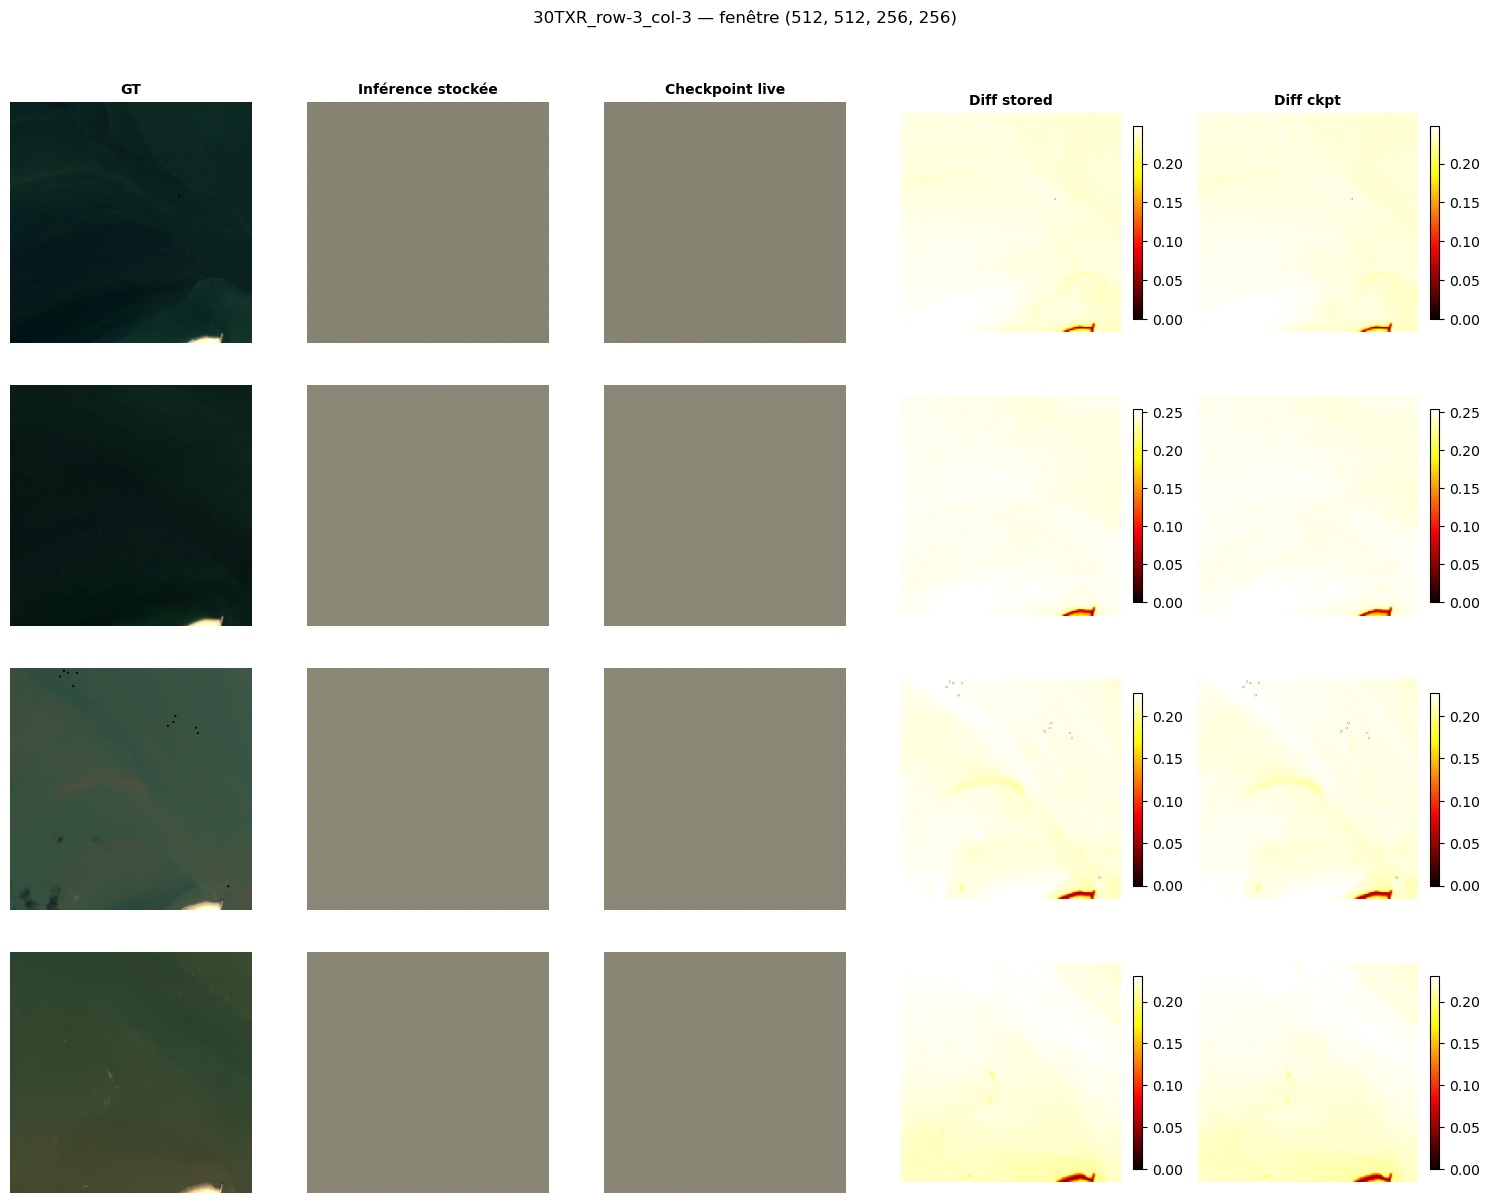

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def to_rgb(arr, indices=RGB_INDICES, brightness=BRIGHTNESS, clip=True):
    """arr : (10, H, W) float32 [0, 1] → (H, W, 3) pour imshow."""
    rgb = arr[indices].transpose(1, 2, 0) * brightness
    return np.clip(rgb, 0, 1) if clip else rgb

def diff_map(pred, gt, valid):
    """Erreur absolue moyenne sur les 10 bandes, masquée par nodata."""
    err = np.abs(pred - gt).mean(axis=0)   # (H, W)
    err[~valid] = np.nan
    return err

n_dates = len(idx_real)
fig, axes = plt.subplots(
    n_dates, 5,
    figsize=(5 * 3, n_dates * 3),
    squeeze=False,
)
col_titles = ["GT", "Inférence stockée", "Checkpoint live",
               "Diff stored", "Diff ckpt"]
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=10, fontweight="bold")

for row, (t_orig, gt_t, st_t, ck_t, valid_t) in enumerate(
    zip(idx_real, gt_valid, stored_valid, ckpt_valid, nodata_mask)
):
    axes[row][0].imshow(to_rgb(gt_t))
    axes[row][1].imshow(to_rgb(st_t))
    axes[row][2].imshow(to_rgb(ck_t))

    d_stored = diff_map(st_t, gt_t, valid_t)
    d_ckpt   = diff_map(ck_t, gt_t, valid_t)
    vmax = np.nanpercentile(np.concatenate([d_stored[valid_t], d_ckpt[valid_t]]), 98)

    im = axes[row][3].imshow(d_stored, cmap="hot", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=axes[row][3], fraction=0.04)
    im = axes[row][4].imshow(d_ckpt, cmap="hot", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=axes[row][4], fraction=0.04)

    axes[row][0].set_ylabel(f"Date orig. {t_orig}", fontsize=8)

for ax in axes.ravel():
    ax.axis("off")

plt.suptitle(f"{MGRS25} — fenêtre {WINDOW}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5 · Métriques par bande

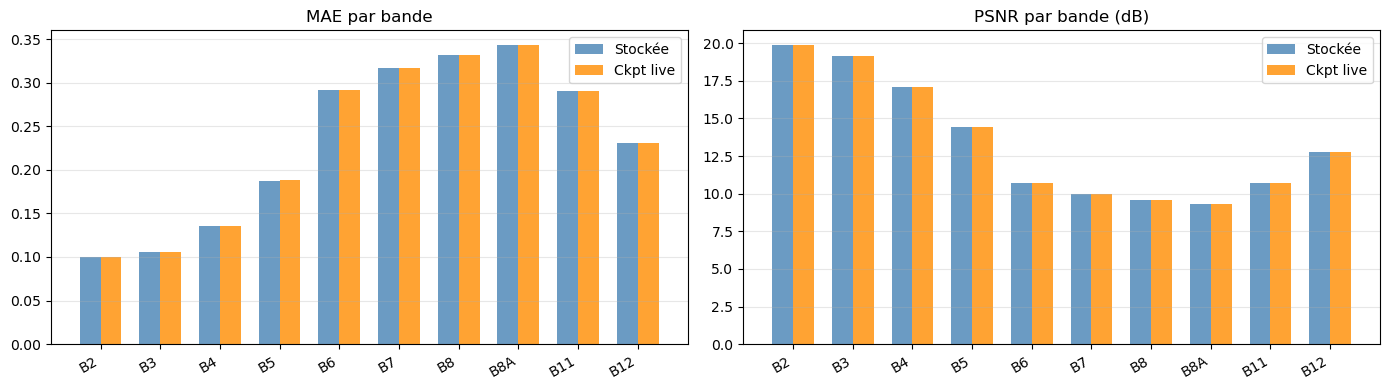

In [8]:
from dataloader_CIRCA.datasets.cr_metrics import CloudRemovalMetrics

def metrics_per_band(pred_np, gt_np, valid_mask_np):
    """Retourne un dict {nom_bande: {metrique: valeur}}."""
    results = {}
    for i, name in enumerate(BAND_NAMES):
        p = pred_np[:, i:i+1]   # (N, 1, H, W)
        g = gt_np[:, i:i+1]
        m = (~valid_mask_np).astype(np.float32)[:, np.newaxis]
        cr = CloudRemovalMetrics(
            eval_occluded_observed=True, clean_gt_cloudy_pixels=False, max_pixel_intensity=1
        )
        raw = cr(
            target  = torch.from_numpy(g).unsqueeze(0).float(),
            masks   = torch.from_numpy(m).unsqueeze(0).float(),
            predicted = torch.from_numpy(p).unsqueeze(0).float(),
        )
        results[name] = {k.replace("_observed_input_pixels",""): v
                         for k, v in raw.items() if "observed_input" in k}
    return results

pb_stored = metrics_per_band(stored_valid, gt_valid, nodata_mask)
pb_ckpt   = metrics_per_band(ckpt_valid,   gt_valid, nodata_mask)

# ── Graphiques MAE et PSNR par bande ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(BAND_NAMES))
w = 0.35

for ax, metric, title in [
    (axes[0], "mae",  "MAE par bande"),
    (axes[1], "psnr", "PSNR par bande (dB)"),
]:
    vals_s = [pb_stored[b].get(metric, np.nan) for b in BAND_NAMES]
    vals_c = [pb_ckpt[b].get(metric, np.nan)   for b in BAND_NAMES]
    ax.bar(x - w/2, vals_s, w, label="Stockée",    color="steelblue",  alpha=0.8)
    ax.bar(x + w/2, vals_c, w, label="Ckpt live",  color="darkorange", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(BAND_NAMES, rotation=30, ha="right")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Scatter plot : prédiction stockée vs checkpoint

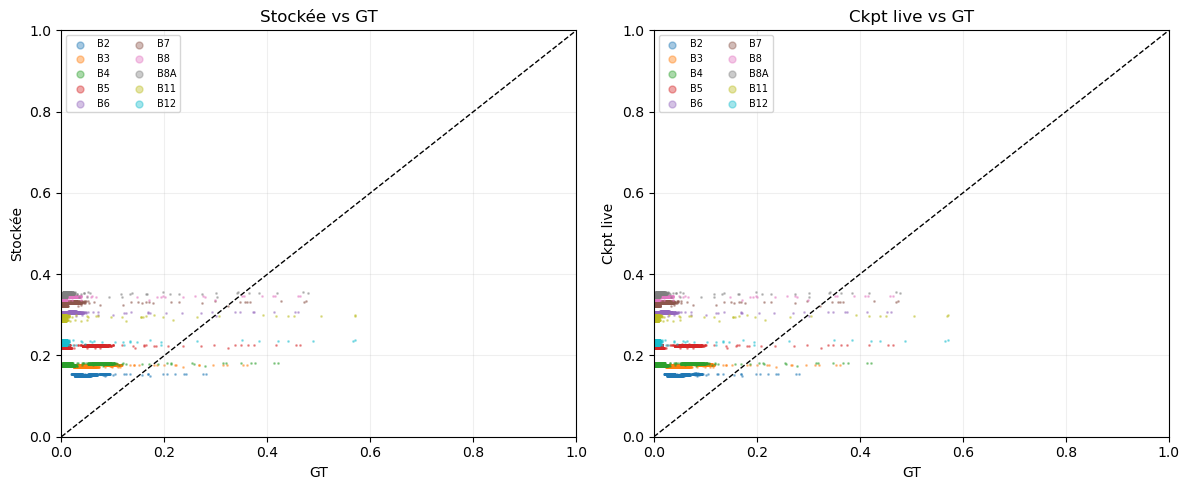

In [9]:
# Scatter : pour chaque pixel valide, compare stored_pred vs ckpt_pred (coloré par bande)
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

valid_flat = nodata_mask.ravel()   # (N*H*W,)

for ax, (pred_a, pred_b, lbl_a, lbl_b) in [
    (axes[0], (stored_valid, gt_valid,   "Stockée",   "GT")),
    (axes[1], (ckpt_valid,   gt_valid,   "Ckpt live", "GT")),
]:
    colors = cm.tab10(np.linspace(0, 1, 10))
    for i, (name, c) in enumerate(zip(BAND_NAMES, colors)):
        p_flat = pred_a[:, i].ravel()[valid_flat]
        g_flat = pred_b[:, i].ravel()[valid_flat]
        # Sous-échantillonnage pour rapidité
        step = max(1, len(p_flat) // 5000)
        ax.scatter(g_flat[::step], p_flat[::step], s=1, color=c, alpha=0.4, label=name)
    lim = (0, 1)
    ax.plot(lim, lim, "k--", linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"{lbl_b}")
    ax.set_ylabel(f"{lbl_a}")
    ax.set_title(f"{lbl_a} vs {lbl_b}")
    ax.legend(markerscale=5, fontsize=7, ncol=2)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7 · Séries temporelles sur un pixel

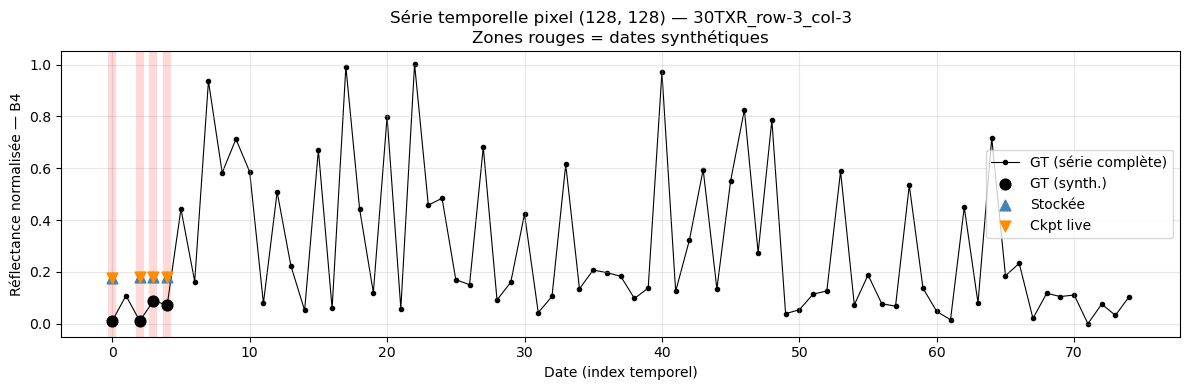

In [10]:
# Pixel à inspecter (dans les coordonnées de la fenêtre)
PIXEL_ROW = win_h // 2
PIXEL_COL = win_w // 2

# Série temporelle complète du GT sur toutes les dates (pas seulement synthétiques)
gt_series_full = to_float(gt_4d[:, :10, PIXEL_ROW, PIXEL_COL])   # (T_tot, 10)

# Valeurs des deux prédictions sur les dates synthétiques
stored_pts = stored_valid[:, :, PIXEL_ROW, PIXEL_COL]   # (N, 10)
ckpt_pts   = ckpt_valid[:, :, PIXEL_ROW, PIXEL_COL]     # (N, 10)
gt_pts     = gt_valid[:, :, PIXEL_ROW, PIXEL_COL]       # (N, 10)

BAND_IDX = 2   # B4 (rouge) pour l'illustration

fig, ax = plt.subplots(figsize=(12, 4))

# GT complet
t_full = np.arange(T_tot)
ax.plot(t_full, gt_series_full[:, BAND_IDX], "k-o", markersize=3,
        linewidth=0.8, label="GT (série complète)", zorder=1)

# Points synthétiques
ax.scatter(idx_real, gt_pts[:, BAND_IDX],     color="black",      s=60, zorder=5, label="GT (synth.)")
ax.scatter(idx_real, stored_pts[:, BAND_IDX], color="steelblue",  s=60, zorder=5, marker="^", label="Stockée")
ax.scatter(idx_real, ckpt_pts[:, BAND_IDX],   color="darkorange", s=60, zorder=5, marker="v", label="Ckpt live")

# Mise en évidence des dates synthétiques
for t in idx_real:
    ax.axvline(t, color="red", alpha=0.15, linewidth=6)

ax.set_xlabel("Date (index temporel)")
ax.set_ylabel(f"Réflectance normalisée — {BAND_NAMES[BAND_IDX]}")
ax.set_title(f"Série temporelle pixel ({PIXEL_ROW}, {PIXEL_COL}) — {MGRS25}\n"
             f"Zones rouges = dates synthétiques")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()